## Population-Based Structural Health Monitoring (PBSHM)

### Objective
Detect whether a structure is damaged using measurement-like features and graph structure.

## Dataset Overview
- 50 structures
- Each has 4–8 storeys
- Structure Features:
  - Structure id (`structure_id`)
  - Number of Storeys (`n_storeys`)
  - Edges (`edges`)
  - Node Features (`n_features`)
  - Feature Names (`feature_names`)

- Node features:
  - Storey (`storey`)
  - height (`height_m`)
  - dominant modal frequency (`dominant_modal_frequency_Hz`)

- Available Structure Labels:
  - Structure id (`structure_id`)
  - Damaged (`damaged`)
  - Damage Storey (`damage_storey`)

In [91]:
"""
Imprting necessary libraries and setting up the environment 
for data analysis and visualization.
"""

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

plt.style.use('seaborn')


### Task1: Population Exploration (EDA)
Characterize the dataset and explain the variation across the population.

- Visualize the distribution of structure sizes and geometry
- Explore the starter population graph
- Inspect the provided measurement-like node features
- Propose which raw or derived features might be damage-sensitive


In [115]:
#-//--------- Data Loading and Preprocessing ---------//-

with open('structures_measurements.json') as f:
    structures = json.load(f)

labels = pd.read_csv('structure_labels.csv')

# Load population graph
edges = pd.read_csv("population_edges_geometry.csv")
weights = pd.read_csv("population_edge_weights_geometry.csv")

# Flatten node data
node_properties = []
for structure in structures:
    structure_id = structure['structure_id']
    n_storeys = structure['n_storeys']
    
    for node in structure['node_features']:
        node_propert = node.copy()
        node_propert['structure_id'] = structure_id
        node_propert['n_storeys'] = n_storeys
        node_properties.append(node_propert)

# Create DataFrame from node properties
nodes_df = pd.DataFrame(node_properties)

# Merge labels with node properties
nodes_df = nodes_df.merge(labels, on='structure_id')

#--//--------- Structure-Level Feature Extraction ---------//-
# Structure-level dataframe
structure_property = []
for structure in structures:
    structure_id = structure['structure_id']
    structure_property.append({
        'structure_id': structure_id,
        'n_storeys': structure['n_storeys'],
        'total_height': sum(n['height_m'] for n in structure['node_features']),
        'damaged': labels.loc[labels.structure_id == structure_id, 'damaged'].values[0]
    })

# Create DataFrame from structure properties
structure_df = pd.DataFrame(structure_property)


#nodes_df.head()
structure_df.head()

,structure_id,n_storeys,total_height,damaged
0,0,6,24.905,0
1,1,5,19.219,0
2,2,8,32.077,0
3,3,6,22.181,1
4,4,7,29.248,1


#### Distribution of Structure Sizes

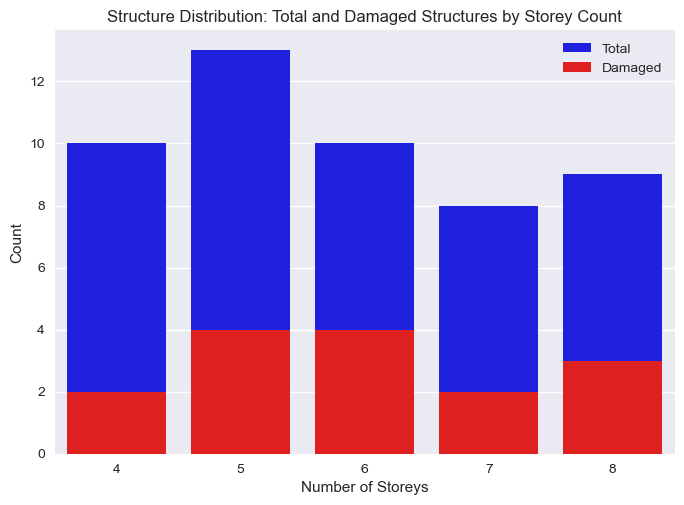

In [104]:
# Structure-level unique data
unique_structure_df = nodes_df[['structure_id', 'n_storeys', 'damaged']].drop_duplicates()

# Total structure count per group
total_counts = unique_structure_df['n_storeys']

# Damaged only
damaged_counts = unique_structure_df[unique_structure_df['damaged'] == 1]['n_storeys']

# Plot
sns.countplot(x=total_counts, color='blue', label='Total')
sns.countplot(x=damaged_counts, color='red', label='Damaged')

plt.title("Structure Distribution: Total and Damaged Structures by Storey Count")
plt.xlabel("Number of Storeys")
plt.ylabel("Count")
plt.legend()
plt.show()

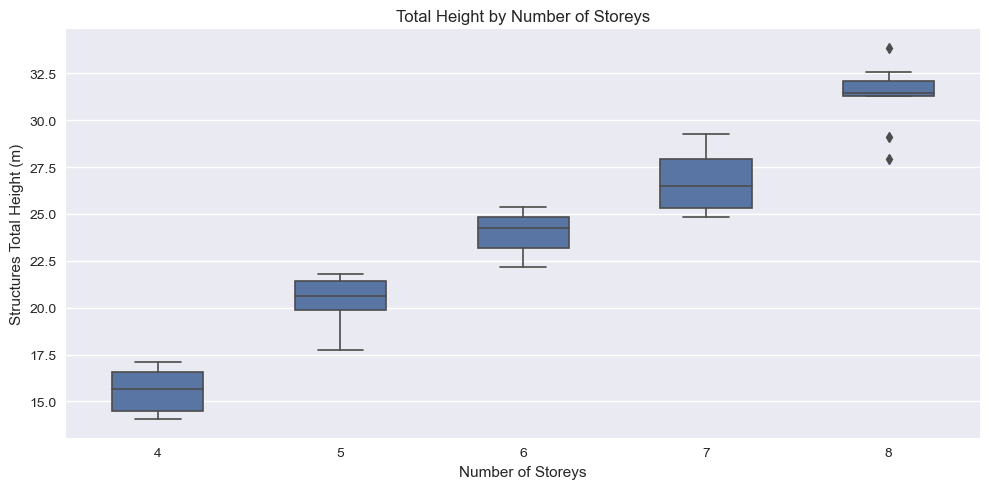

- Hights are relatively well distributed across each story in a Structure group

#### Starter population graph

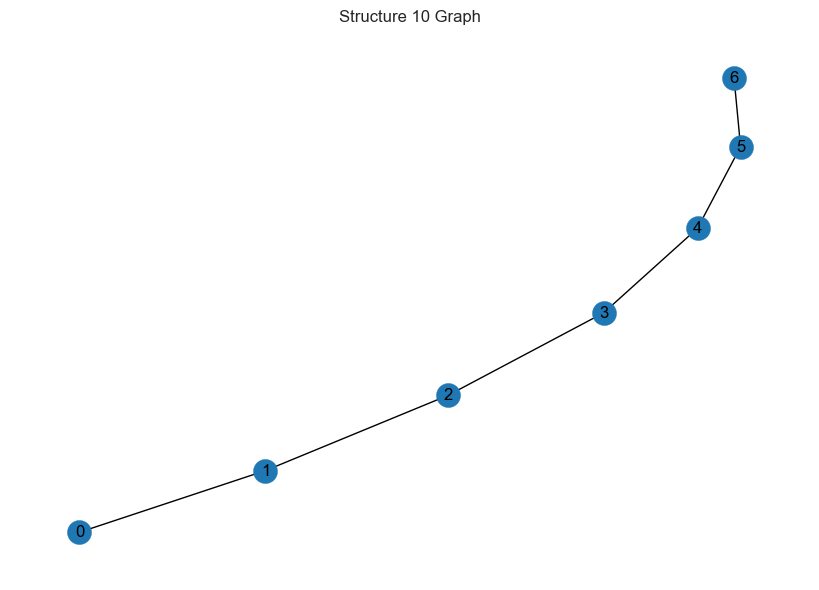

In [114]:
# Structure-level graph visualization
sample_structure = structures[10]

sample_structure_graph = nx.Graph()
sample_structure_graph.add_edges_from(sample_structure['edges'])

nx.draw(sample_structure_graph, with_labels=True)
plt.title(f"Structure {sample_structure['structure_id']} Graph")
plt.show()

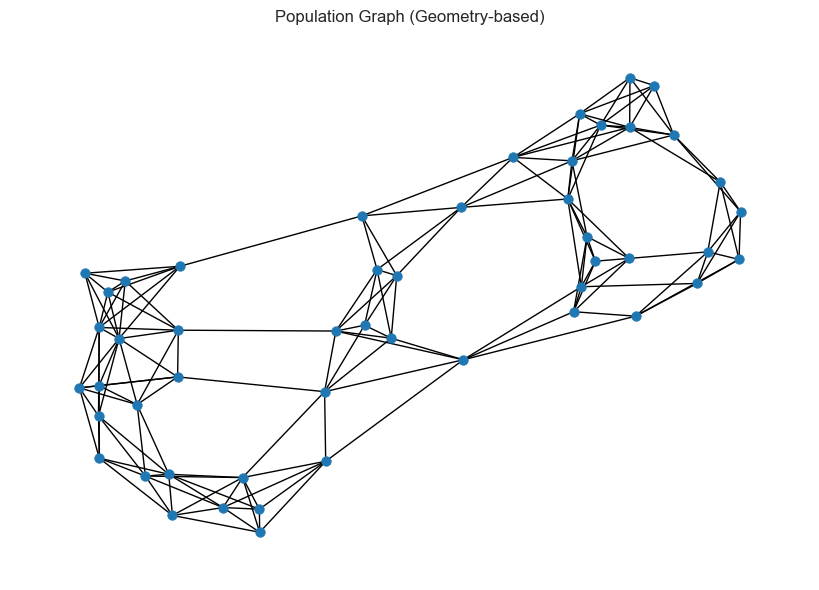

In [118]:
# Population graph visualization
structure_pop_graph = nx.from_pandas_edgelist(edges, 'source', 'target')

nx.draw(structure_pop_graph, node_size=50)
plt.title("Population Graph (Geometry-based)")

plt.show()

#### Inspection of Node features Measurement



In [121]:
nodes_df.head()

,storey,height_m,dominant_modal_frequency_Hz,structure_id,n_storeys,damaged,damage_storey
0,0,3.532,2.66633,0,6,0,NaN
1,1,4.938,8.06059,0,6,0,NaN
2,2,4.558,4.46783,0,6,0,NaN
3,3,4.434,2.66633,0,6,0,NaN
4,4,3.899,5.19604,0,6,0,NaN


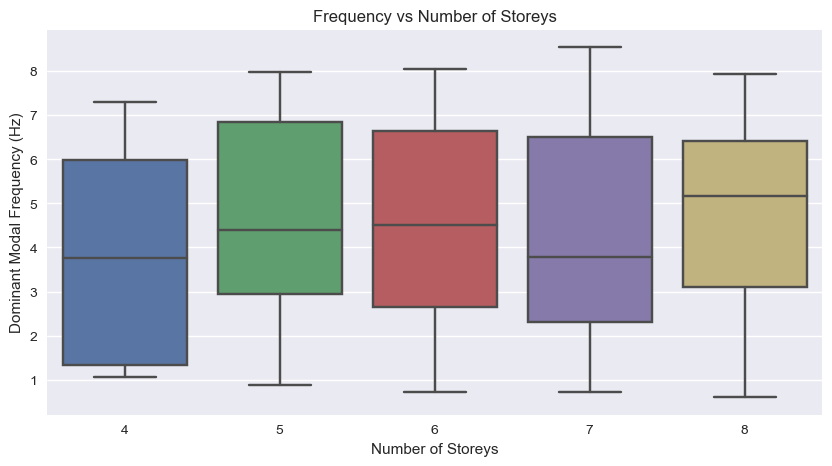

In [134]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=nodes_df,
    x='n_storeys',
    y='dominant_modal_frequency_Hz'
    #hue='damaged',
   
)
plt.title("Frequency vs Number of Storeys")
plt.xlabel("Number of Storeys")
plt.ylabel("Dominant Modal Frequency (Hz)") 
plt.show()

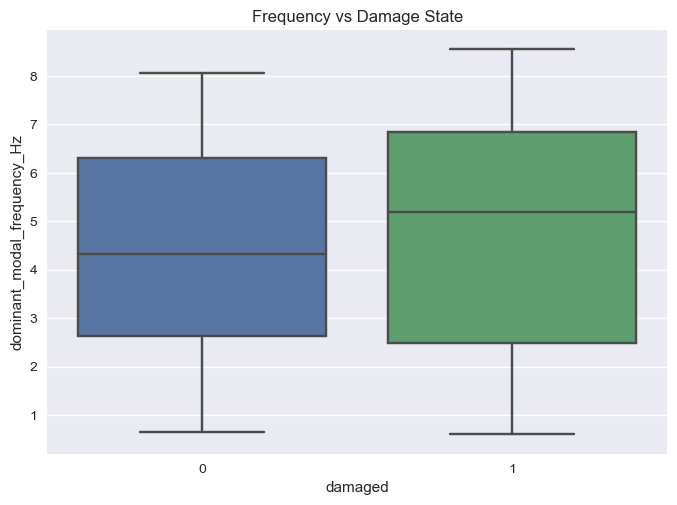

In [156]:
sns.boxplot(
    data=nodes_df,
    x='damaged',
    y='dominant_modal_frequency_Hz'
)
plt.title("Frequency vs Damage State")
plt.show()

Observation: 
- Significant overlap between classes
But: *Damaged structures show slightly more spread values*

Key takeaway:
Raw frequency alone is not sufficient, but still informative

- 

#### Feature Engineering Frequency Data (A dynamic Variable)

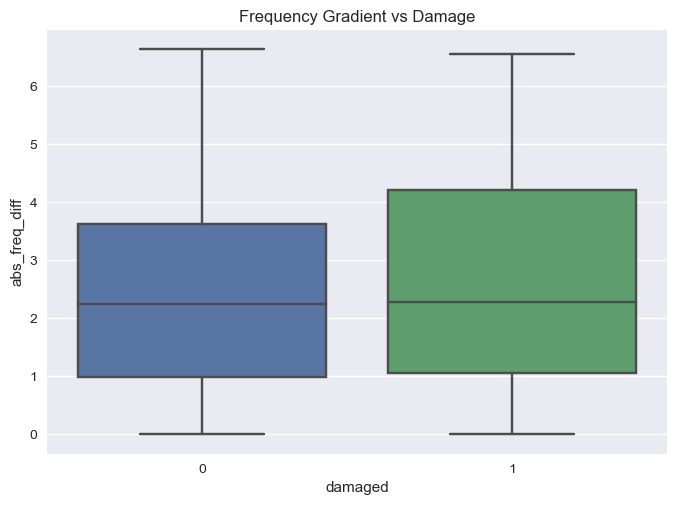

In [163]:
nodes_df['freq_diff'] = nodes_df.groupby('structure_id')['dominant_modal_frequency_Hz'].diff()
nodes_df['abs_freq_diff'] = nodes_df['freq_diff'].abs() # Intrested in Magnitude of change not direction

sns.boxplot(data=nodes_df, x='damaged', y='abs_freq_diff')
plt.title("Frequency Gradient vs Damage")
plt.show()

High overlap between classes
Slightly higher variability in damaged structures
- Damage introduces local irregularities, not consistent shifts?*

### Normalized frequency

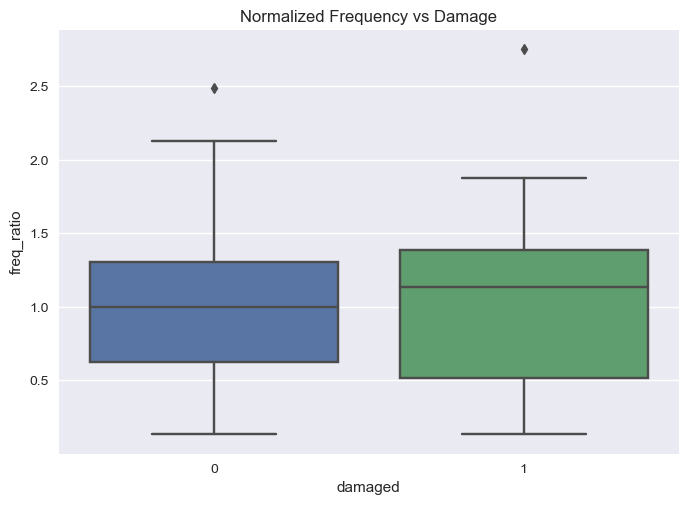

In [164]:
nodes_df['freq_ratio'] = nodes_df['dominant_modal_frequency_Hz'] / \
    nodes_df.groupby('structure_id')['dominant_modal_frequency_Hz'].transform('mean')

sns.boxplot(data=nodes_df, x='damaged', y='freq_ratio')
plt.title("Normalized Frequency vs Damage")
plt.show()

#### Frequency Local Deviation

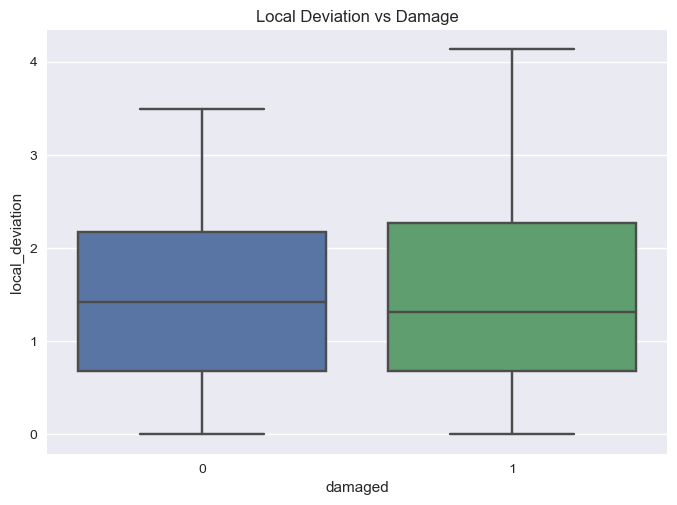

In [165]:
nodes_df['neighbor_mean'] = nodes_df.groupby('structure_id')['dominant_modal_frequency_Hz'] \
    .transform(lambda x: x.rolling(3, center=True).mean())

nodes_df['local_deviation'] = abs(
    nodes_df['dominant_modal_frequency_Hz'] - nodes_df['neighbor_mean']
)

sns.boxplot(data=nodes_df, x='damaged', y='local_deviation')
plt.title("Local Deviation vs Damage")
plt.show()

In [167]:
structure_df.head()

,structure_id,dominant_modal_frequency_Hz_mean,dominant_modal_frequency_Hz_std,abs_freq_diff_max,abs_freq_diff_mean,local_deviation_mean,local_deviation_max,damaged,damage_storey
0,0,3.977460,2.525202,5.39426,3.541326,1.835633,2.995673,0,NaN
1,1,5.345074,2.019452,2.61087,1.204308,0.594373,0.870290,0,NaN
2,2,5.263772,1.184323,2.27024,1.513224,0.792982,1.418457,0,NaN
3,3,5.355862,2.556491,5.47865,3.470660,1.978627,2.891253,1,0.0
4,4,4.615880,2.340717,6.23002,2.759765,1.553599,3.575503,1,4.0


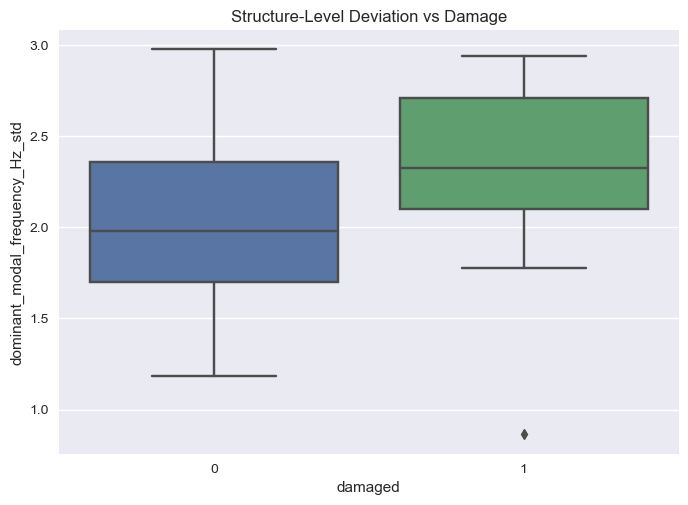

In [172]:
structure_df = nodes_df.groupby('structure_id').agg({
    'dominant_modal_frequency_Hz': ['mean', 'std'],
    'abs_freq_diff': ['max', 'mean'],
    'local_deviation': ['mean', 'max'],
    'n_storeys': 'first'
})

structure_df.columns = ['_'.join(col) for col in structure_df.columns]
structure_df = structure_df.reset_index()
structure_df = structure_df.merge(labels, on='structure_id')


sns.boxplot(data=structure_df, x='damaged', y='dominant_modal_frequency_Hz_std')
plt.title("Structure-Level Deviation vs Damage")
plt.show()

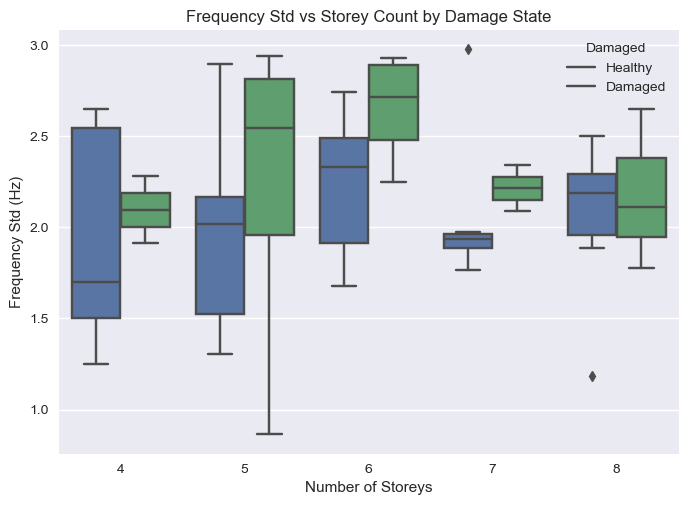

In [176]:
# Plot: 5 pairs of boxplots (one per storey group)
sns.boxplot(
    data=structure_df,
    x='n_storeys_first',                          # groups (4–8)
    y='dominant_modal_frequency_Hz_std',    # feature
    hue='damaged'                           # pairs (0 vs 1)
)

plt.title("Frequency Std vs Storey Count by Damage State")
plt.xlabel("Number of Storeys")
plt.ylabel("Frequency Std (Hz)")
plt.legend(title="Damaged", labels=["Healthy", "Damaged"])
plt.show()

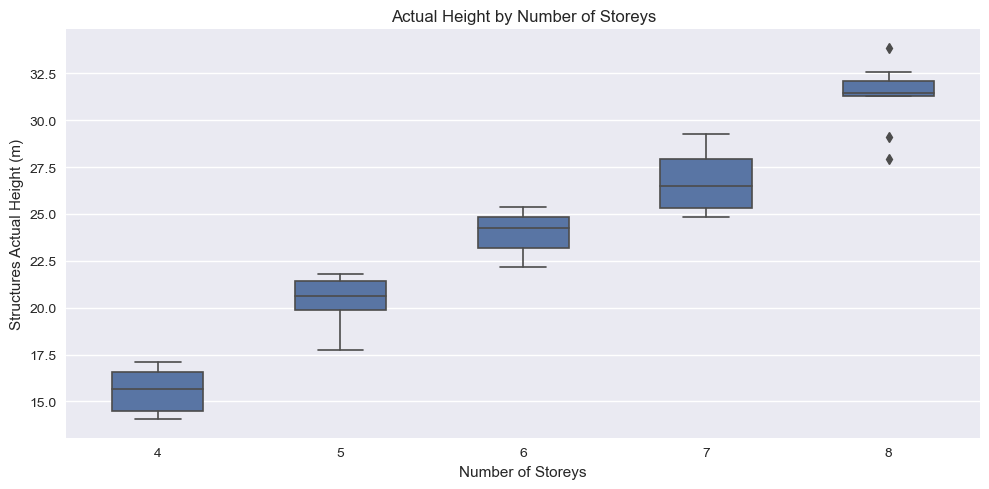

In [130]:
# Boxplot of Structure total height by number of storeys
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=structure_df,
    x='n_storeys',
    y='total_height',
    color='#4C72B0',   # clean, professional blue
    width=0.5,
    linewidth=1.2
)

plt.title("Actual Height by Number of Storeys")
plt.xlabel("Number of Storeys")
plt.ylabel("Structures Actual Height (m)")
plt.tight_layout()
plt.show()

Observation: Structure Hight correlates strongly with Number of Stories, thought slight local variations in the node level

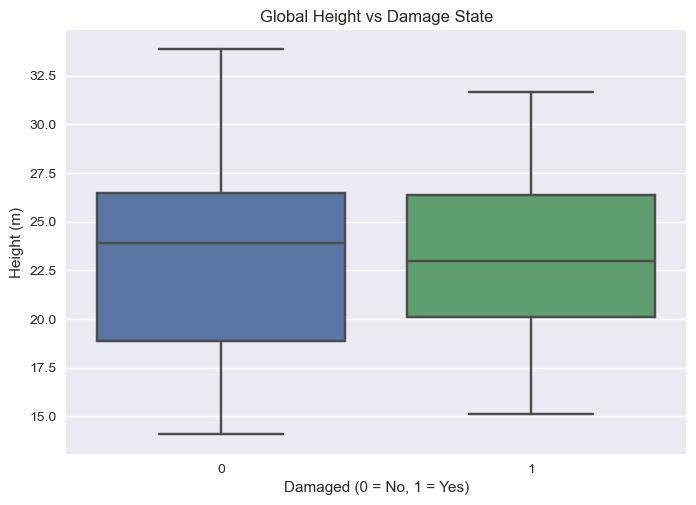

In [161]:
sns.boxplot(
    data=structure_df,
    x='damaged',
    y='total_height',
)
plt.title("Global Height vs Damage State")
plt.xlabel("Damaged (0 = No, 1 = Yes)")
plt.ylabel("Height (m)")
plt.show()

## Distribution of Structure Sizes and Geometry

### Key Observations

   - Total height increases consistently with the number of storeys
   - Each storey group forms a distinct cluster, indicating a near-linear relationship
   - Structures with the same number of storeys exhibit similar total heights
   - This sugest geometric simmilarities across the Population groups (Good for PBSHM)

   - The distributions of total height for damaged and undamaged structures almost overlap completely. Very little visible shift in median or spread is observed, some variation exists due to differences in individual storey heights

### Insight from the EDA

- Structural geometry is primarily determined by the number of storeys
- The dataset exhibits consistent geometric properties across the population
- Though the structural heigth data is not directly damage-sensitive, but by physics intuition it:
  - Influences stiffness and mass distribution
  - Helps categories structures in a population.
